In [260]:
# Checking spatial convergence and rayleigh damping for the gap flow.

In [261]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib.colors as colors

In [262]:
def z_interp(h, field_vals_all, lon, lat, z_val):
    field_vals = np.zeros((len(lat), len(lon)))
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if h[-1,i,j] > z_val:
                # This value is inside the topography
                field_vals[i,j] = np.nan
            else:
                # Find indices either side of this value
                low_idx = np.where(h[:,i,j] < z_val)[0][0]
                high_idx = np.where(h[:,i,j] > z_val)[0][-1]

                # Compute weightings
                weight_low = (z_val - h[low_idx,i,j])/(h[high_idx,i,j] - h[low_idx,i,j])
                weight_high = 1. - weight_low

                # Compute and store value
                field_vals[i,j] = weight_low*field_vals_all[low_idx, i, j] + weight_high*field_vals_all[high_idx, i, j]
    return field_vals

In [263]:
rot = False
u = 10

dycore = 'se'

#res = 'ne30'
res = 'ne60'

lev_no1 = 'ztop20km_L52'
#lev_no2 = 'ztop20km_L63'
#lev_no2 = 'ztop20km_L200'
lev_no2 = 'ztop20km_L56'
#lev_no3 = 'ztop20km_L74'
lev_no3 = 'ztop20km_L73'

extra_name1 = 'tau_1_2'
extra_name2 = 'tau_1_2'
extra_name3 = 'tau_1_2'

#lev_no1 = 'ztop20km_L43'
#lev_no2 = 'ztop20km_L45'
#lev_no3 = 'ztop20km_L52'

#extra_name1 = 'tau1_2_short_gap'
#extra_name2 = 'tau_1_2_short_gap'
#extra_name3 = 'tau1_2_short_gap'

CAM_branch = 'CAM_6_4_100_11082025'

#test_name_start = 'cam_6_4_100_gap'
test_name_start = 'cam_6_4_100'

case1 = f'{test_name_start}_{dycore}_{res}_{lev_no1}'
case2 = f'{test_name_start}_{dycore}_{res}_{lev_no2}'
case3 = f'{test_name_start}_{dycore}_{res}_{lev_no3}'


# Compare three files
if rot:
    #nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_with_rot_{extra_name1}'
    #nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_with_rot_{extra_name2}'
    #nc_file3 = f'{case3}.cam.h0i.0001-01-01-00000_with_rot_{extra_name3}'
    nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name1}'
    nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name2}'
    nc_file3 = f'{case3}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name3}'
else:
    #nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_omega0_{extra_name1}'
    #nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_omega0_{extra_name2}'
    #nc_file3 = f'{case3}.cam.h0i.0001-01-01-00000_omega0_{extra_name3}'
    nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name1}'
    nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name2}'
    nc_file3 = f'{case3}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name3}'

if dycore ==  'fv3':
    nc_file1 = f'{nc_file1}.regrid.1x1'

nc_file1 = nc_file1 + '.nc'
nc_file2 = nc_file2 + '.nc'
nc_file3 = nc_file3 + '.nc'

In [264]:
run_base = "/glade/derecho/scratch/timand/"

run_path1 = run_base + case1 + '/run/' + nc_file1
run_path2 = run_base + case2 + '/run/' + nc_file2
run_path3 = run_base + case3 + '/run/' + nc_file3

nc1 = Dataset(run_path1)
nc2 = Dataset(run_path2)
nc3 = Dataset(run_path3)

In [265]:
time = nc1['time'][:]
lat = nc1['lat'][:] 
lon = nc1['lon'][:] 

In [266]:
# Specify the size of the lon-lat crop, which
# will be centred around the equator for lat
lat_crop_up = 50.
lat_cent_down = -50.

lat_ticks = np.linspace(-40,40,5)

lon_crop_left = 60.

if rot == True:
    lon_crop_right = 170.
    lon_ticks = np.linspace(80, 160, 5)
else:
    lon_crop_right = 150.
    lon_ticks = np.linspace(80, 140, 4)

lon_inds = np.where((lon < lon_crop_right) & (lon > lon_crop_left))[0]
lat_inds = np.where((lat < lat_crop_up) & (lat > lat_cent_down))[0]

lat = lat[lat_inds]
lon = lon[lon_inds]

LON, LAT = np.meshgrid(lon, lat)

In [267]:
# Field to compare
field = 'T'

# Time index to compare at
t_idx = 40

# z level to compare at, in m.
# For reference, the Gabersek, Durran paper
# plots at z = 300 m.
z_val = 300

# Choice of colormap
# Choice of colormap
if field == 'T':        
    cmap_choice = 'jet'
else:
    #cmap_choice = 'seismic'
    #cmap_choice='jet'
    cmap_choice = 'RdYlBu_r'

In [268]:
# Interpolations:
field_vals1 = z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1[field][t_idx, :, lat_inds, lon_inds], lon, lat, z_val)
field_vals2 = z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2[field][t_idx, :, lat_inds, lon_inds], lon, lat, z_val)
field_vals3 = z_interp(nc3['Z3'][t_idx, :, lat_inds, lon_inds], nc3[field][t_idx, :, lat_inds, lon_inds], lon, lat, z_val)

In [269]:
deg2rad = np.pi/180
T0 = 288

if field == 'U':
    # Normalised velocity perturbation:
        field_vals1 = (field_vals1 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
        field_vals2 = (field_vals2 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
        field_vals3 = (field_vals3 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
else:
    # Temperature perturbation:
        field_vals1 = field_vals1 - T0
        field_vals2 = field_vals2 - T0
        field_vals3 = field_vals3 - T0

min value is -1.7069230123712487
max value is 7.524402941083167


Text(0.5, 0.01, 'Longitude (deg)')

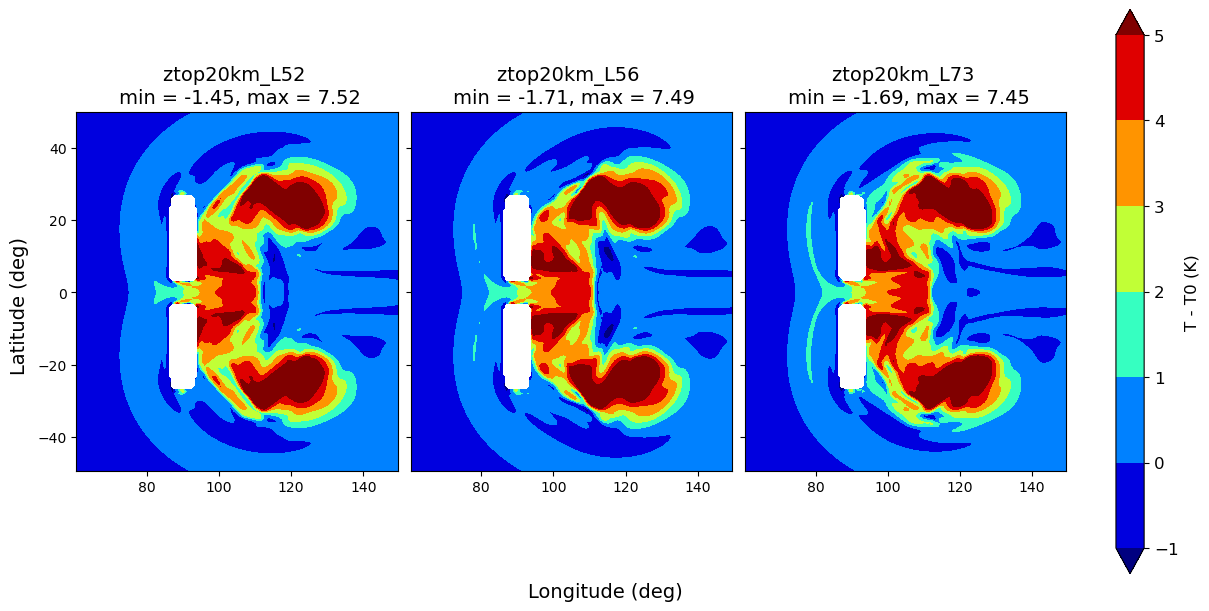

In [270]:
title_size=16
label_size=14
small_size=12

max1 = np.nanmax(field_vals1)
max2 = np.nanmax(field_vals2)
max3 = np.nanmax(field_vals3)

min1 = np.nanmin(field_vals1)
min2 = np.nanmin(field_vals2)
min3 = np.nanmin(field_vals3)

maxmax = max(max1, max2, max3)
minmin = min(min1, min2, min3)

print('min value is', minmin)
print('max value is', maxmax)

conts = np.linspace(minmin, maxmax, 21)

fig, axes = plt.subplots(1,3, sharey=True, figsize = (12,6), layout="constrained")
(ax1, ax2, ax3) = axes

if field == 'T':
    if rot:
        conts = np.linspace(-1, 5, 7)
        norm = colors.Normalize(vmin=-1, vmax=5)
        tick_range = np.linspace(-1, 5, 7)
    else:
        conts = np.linspace(-1, 5, 7)
        norm = colors.Normalize(vmin=-1, vmax=5)
        tick_range = np.linspace(-1, 5, 7)
    plot1 = ax1.contourf(LON, LAT, field_vals1, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot2 = ax2.contourf(LON, LAT, field_vals2, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot3 = ax3.contourf(LON, LAT, field_vals3, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    title = 'Temperature perturbation'
    cb_label = 'T - T0 (K)'
else:
    if rot:
        conts = np.linspace(-2.0, 2.0, 9)
        tick_range = np.linspace(-2.0, 2.0, 9)
        norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)
    else:
        conts = np.linspace(-1.5, 1.0, 11)
        tick_range = np.linspace(-1.5, 1.0, 6)
        norm = colors.TwoSlopeNorm(vmin=-1.5, vcenter=0, vmax=1.0)
    plot1 = ax1.contourf(LON, LAT, field_vals1, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot2 = ax2.contourf(LON, LAT, field_vals2, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot3 = ax3.contourf(LON, LAT, field_vals3, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    title = 'Normalised velocity perturbation'
    cb_label = '$(u(t) - u_0)/u_0$'

ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax3.set_aspect('equal')

cb = plt.colorbar(plot3, ax=axes, ticks = tick_range, fraction=0.4)
cb.set_label(label=cb_label, size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f'{lev_no1} \n min = {np.round(min1,2)}, max = {np.round(max1,2)}', size=label_size)
ax2.set_title(f'{lev_no2} \n min = {np.round(min2,2)}, max = {np.round(max2,2)}', size=label_size)
ax3.set_title(f'{lev_no3} \n min = {np.round(min3,2)}, max = {np.round(max3,2)}', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

In [271]:
#Lat vert cross sections:
lon = nc1['lon'][:] 
lat = nc1['lat'][:] 

lev1 = nc1['lev'][:] 
lev2 = nc2['lev'][:]
lev3 = nc3['lev'][:]

lon_crop_left = 50
lon_crop_right = 150

# User parameters:
t_idx = -1
field = 'W'

lon_ticks = np.linspace(lon_crop_left, lon_crop_right, 5)

lon_crop_inds = np.where((lon < lon_crop_right) & (lon > lon_crop_left))
lon_crop = lon[lon_crop_inds]

LONGC1, P1 = np.meshgrid(lon_crop, lev1) 
LONGC2, P2 = np.meshgrid(lon_crop, lev2) 
LONGC3, P3 = np.meshgrid(lon_crop, lev3) 

# Pick the latitude to slice at:
# For one degree
#lat_val = 95
# For half-degree
lat_val = 190

lat_val_deg = np.round(lat[lat_val],0)
print('lat in deg is', lat_val_deg)


if field=='W':
    Rd = 287.04
    g = 9.80616
    # Convert P from hPa to Pa
    field1 = (Rd/g)*nc1['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc1['T'][t_idx, :, lat_val, lon_crop_inds[0]]/(P1*100)
    field2 = (Rd/g)*nc2['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc2['T'][t_idx, :, lat_val, lon_crop_inds[0]]/(P2*100)
    field3 = (Rd/g)*nc3['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc3['T'][t_idx, :, lat_val, lon_crop_inds[0]]/(P3*100)
else:
    field1 = nc1[field][t_idx, :, lat_val, lon_crop_inds[0]]
    field2 = nc2[field][t_idx, :, lat_val, lon_crop_inds[0]]
    field3 = nc3[field][t_idx, :, lat_val, lon_crop_inds[0]]

ps_t = nc1['PS'][t_idx, lat_val, lon_crop_inds[0]]/100

cmap_choice = 'coolwarm'

lat in deg is 5.0


Text(0.5, 1.0, 'ztop20km_L73 \n \n min = -0.530 m/s \n max = 2.093 m/s')

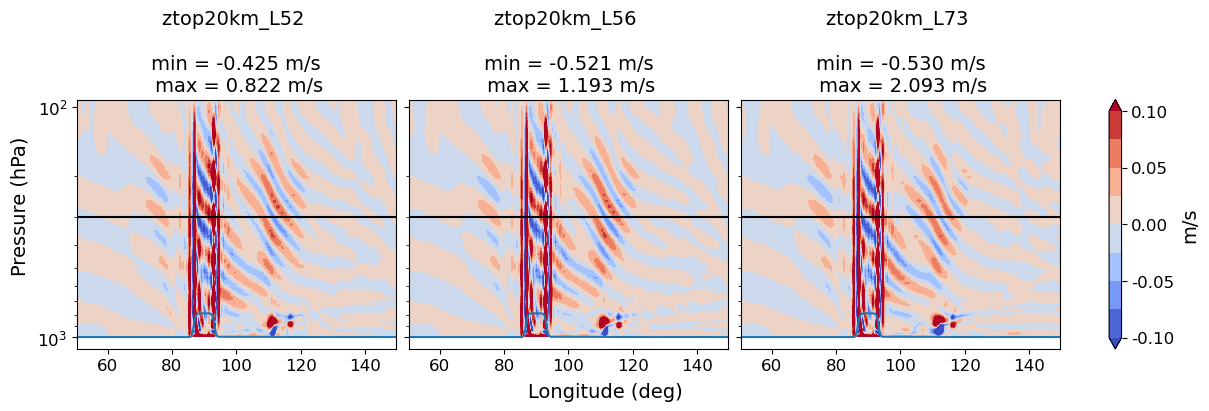

In [272]:
max1 = np.nanmax(field1)
max2 = np.nanmax(field2)
max3 = np.nanmax(field3)

min1 = np.nanmin(field1)
min2 = np.nanmin(field2)
min3 = np.nanmin(field3)

fig, axes = plt.subplots(1,3,figsize = (12,4), sharey=True, constrained_layout=True)
(ax1, ax2, ax3) = axes

minmin = -0.1
maxmax = 0.1
absmax = max(abs(minmin), abs(maxmax))
norm = colors.TwoSlopeNorm(vmin=minmin, vcenter=0, vmax=maxmax)
conts = np.linspace(minmin, maxmax, 9)
tick_range = np.linspace(minmin, maxmax, 5)
plot1 = ax1.contourf(LONGC1, P1, field1, levels = conts, cmap=cmap_choice, extend='both')
plot2 = ax2.contourf(LONGC2, P2, field2, levels = conts, cmap=cmap_choice, extend='both')
plot3 = ax3.contourf(LONGC3, P3, field3, levels = conts, cmap=cmap_choice, extend='both')
title = 'W'
cb_label = 'm/s'
unit = 'm/s'

cb = plt.colorbar(plot3,ax=axes,pad=0.05,shrink=1,format='%.2f', ticks = tick_range)
cb.ax.tick_params(labelsize=12)
cb.set_label('m/s', size=14)

ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')

fig.supylabel('Pressure (hPa)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

ax1.invert_yaxis()

# Plot the sponge layer start:
pc = 301.82
pc_low =552.4

ax1.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')
ax2.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')
ax3.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')

# Add the surface topography:
ax1.plot(lon_crop, ps_t)
ax2.plot(lon_crop, ps_t)
ax3.plot(lon_crop, ps_t)

ax1.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax3.tick_params(axis='both', which='major', labelsize=12)

ax1.set_title(f'{lev_no1} \n \n min = {min1:.3f} m/s \n max = {max1:.3f} m/s', size=label_size)
ax2.set_title(f'{lev_no2} \n \n min = {min2:.3f} m/s \n max = {max2:.3f} m/s', size=label_size)
ax3.set_title(f'{lev_no3} \n \n min = {min3:.3f} m/s \n max = {max3:.3f} m/s', size=label_size)

In [273]:
# What about interpolations onto z coordinates?